In [1]:
import math 
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# # --- physical properties ---
# rho = 1000       # kg/m3
# g = 9.81         # m/s2
# mu = 1e-3        # Pa·s

# # --- permeability ---
# k_intrinsic = 1e-12   # m2 (FIXED: realistic!)
# K = k_intrinsic * rho * g / mu   # hydraulic conductivity

# # --- geometry ---
# r_sample = 0.01   # m
# r_pipe   = 0.005  # m
# L        = 0.1    # m

# # --- experiment input ---
# V_added = 1e-4   # m3 (100 mL)

# # --- time ---
# t_end = 60000
# dt = 0.1   # FIXED: smaller timestep

In [3]:
# def falling_head(
#     t_end,
#     dt,
#     K,
#     r_sample,
#     r_pipe,
#     L,
#     V_added
# ):

#     t = np.arange(0, t_end + dt, dt)

#     h = np.zeros_like(t)
#     Q = np.zeros_like(t)
#     v = np.zeros_like(t)

#     # areas
#     A_sample = math.pi * r_sample**2
#     A_pipe   = math.pi * r_pipe**2

#     # initial head from volume
#     h[0] = V_added / A_pipe

#     for i in range(1, len(t)):

#         # Darcy flow
#         Q[i-1] = K * A_sample * h[i-1] / L

#         # velocity
#         v[i-1] = Q[i-1] / A_sample

#         # head decay
#         dhdt = -Q[i-1] / A_pipe

#         # update (stable)
#         h[i] = max(h[i-1] + dhdt * dt, 0)

#     return t, h, Q, v

In [4]:
# t, h, Q, v = falling_head(
#     t_end,
#     dt,
#     K,
#     r_sample,
#     r_pipe,
#     L,
#     V_added
# )

In [5]:
# volumes = [5e-5, 1e-4, 2e-4]

# plt.figure()

# for V in volumes:
#     t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L, V)
#     plt.plot(t, Q, label=f"V={V} m³")

# plt.legend()
# plt.xlabel("Time (s)")
# plt.ylabel("Volumetric flow rate")
# plt.title("Effect of added volume")
# plt.grid()
# plt.savefig("added_water_volume_Q_time_effect.png", dpi=300)
# plt.show()

In [6]:
# lengths = [0.05, 0.1, 0.2]

# plt.figure()

# for L_val in lengths:
#     t, Q, _, _ = falling_head(t_end, dt, K, r_sample, r_pipe, L_val, V_added)
#     plt.plot(t, Q, label=f"L={L_val} m")

# plt.legend()
# plt.xlabel("Time (s)")
# plt.ylabel("Volumetric flow rate (m)")
# plt.title("Effect of sample length")
# plt.grid()
# plt.savefig("sample_length_Q_time_effect.png",dpi=300)
# plt.show()

In [7]:
# radii = [0.005, 0.01, 0.02]

# plt.figure()

# for r in radii:
#     t, Q, _, _ = falling_head(t_end, dt, K, r, r_pipe, L, V_added)
#     plt.plot(t, Q, label=f"r_sample={r} m")

# plt.legend()
# plt.xlabel("Time (s)")
# plt.ylabel("Volumetric flow rate (m)")
# plt.title("Effect of sample radius")
# plt.grid()
# plt.savefig("sample_radius_Q_time_effect",dpi=300)
# plt.show()

# concentration vs volume estimate


Assume Oyster shells used; have a dry weight that we estimate to consist for 95\% of CaCO3. 

We assume dissolution first; use dissolution rate laws; so related to the grain geometry





In [8]:
def surf_area_to_mass(grainsizes): 

    rho=2.63 #gr/cm3

    surf_area=6/(rho*grainsizes)

    return(surf_area)


In [9]:
grainsizes=np.array([85,400,600])/10000



In [10]:
grainsizes #cm

array([0.0085, 0.04  , 0.06  ])

In [11]:
surf_area_to_mass(grainsizes) #cm2 to gr

array([268.39633192,  57.03422053,  38.02281369])

In [12]:
def surf_area(grainsizes): 

    surf_area= 6*(grainsizes**2)
    return surf_area

In [33]:
surf_area=surf_area(grainsizes)

In [16]:
reaction_rates=np.array([0.69,1.19, 1.19])*10**(-10)

In [17]:
reaction_rates

array([6.90e-11, 1.19e-10, 1.19e-10])

In [18]:
time=np.linspace(0,3600*4,20)

In [19]:
def moles_diss(reaction_rates, grainsizes, time):
    
    n=[]
    for i in range(len(grainsizes)): 
            mol=reaction_rates[i]*surf_area(grainsizes)[i]*time
            n.append(mol)

    return(n)


In [20]:
n=moles_diss(reaction_rates, grainsizes, time)

In [21]:
n

[array([0.00000000e+00, 2.26697684e-11, 4.53395368e-11, 6.80093053e-11,
        9.06790737e-11, 1.13348842e-10, 1.36018611e-10, 1.58688379e-10,
        1.81358147e-10, 2.04027916e-10, 2.26697684e-10, 2.49367453e-10,
        2.72037221e-10, 2.94706989e-10, 3.17376758e-10, 3.40046526e-10,
        3.62716295e-10, 3.85386063e-10, 4.08055832e-10, 4.30725600e-10]),
 array([0.00000000e+00, 8.65818947e-10, 1.73163789e-09, 2.59745684e-09,
        3.46327579e-09, 4.32909474e-09, 5.19491368e-09, 6.06073263e-09,
        6.92655158e-09, 7.79237053e-09, 8.65818947e-09, 9.52400842e-09,
        1.03898274e-08, 1.12556463e-08, 1.21214653e-08, 1.29872842e-08,
        1.38531032e-08, 1.47189221e-08, 1.55847411e-08, 1.64505600e-08]),
 array([0.00000000e+00, 1.94809263e-09, 3.89618526e-09, 5.84427789e-09,
        7.79237053e-09, 9.74046316e-09, 1.16885558e-08, 1.36366484e-08,
        1.55847411e-08, 1.75328337e-08, 1.94809263e-08, 2.14290189e-08,
        2.33771116e-08, 2.53252042e-08, 2.72732968e-08, 2.92

In [22]:
molarmass_calc=100.09 #g/mol 

In [24]:
g=[]
for i in range(len(grainsizes)): 
    mass=molarmass_calc*n[i]
    g.append(mass)

In [30]:
volume=grainsizes**3

In [ ]:
volume #cm3

array([6.14125e-07, 6.40000e-05, 2.16000e-04])

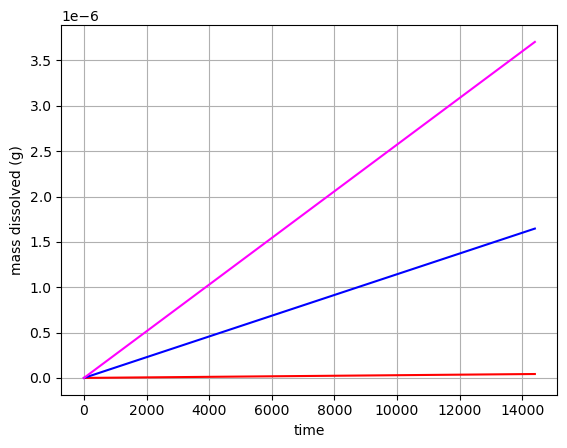

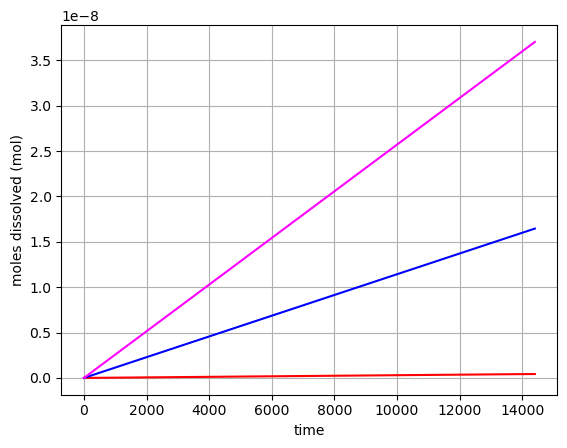

In [29]:
colors=['red','blue','magenta']
for i in range(len(grainsizes)): 
    plt.plot(time, g[i], color=colors[i])
plt.xlabel('time')
plt.ylabel('mass dissolved (g)')
plt.grid()
plt.show()


colors=['red','blue','magenta']
for i in range(len(grainsizes)): 
    plt.plot(time, n[i], color=colors[i])
plt.xlabel('time')
plt.ylabel('moles dissolved (mol)')
plt.grid()
plt.show()

In [32]:
V_setup=150 #cm3; 150ml 

numb_particles=150/volume

In [34]:
numb_particles

array([2.44249949e+08, 2.34375000e+06, 6.94444444e+05])

In [37]:
surf_area

array([0.0004335, 0.0096   , 0.0216   ])

In [42]:
total_react_surf=[]

for i in range(len(surf_area)): 

    react_s=surf_area[i]*numb_particles[i]
    print(react_s)
    total_react_surf.append(react_s)

total_react_surf=np.array(total_react_surf)

105882.35294117648
22499.999999999996
15000.000000000004


In [43]:
total_react_surf

array([105882.35294118,  22500.        ,  15000.        ])

In [44]:
reaction_rate_s_cm2=0.4*10**(-6) #for pH=2.5, per second 


react_rate_total=reaction_rate_s_cm2*total_react_surf

In [ ]:
react_rate_total  #mol/s for whole thing 

array([0.04235294, 0.009     , 0.006     ])